In [61]:
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

In [2]:
if not os.path.exists(os.path.normpath('figures/')):
    os.makedirs(os.path.normpath('figures/'))

# Fig. 1

In [ ]:
color_dict = {
    'FMS': 'tab:blue',
    'NeuroSAT': 'tab:orange',
    'SP': 'tab:green',
    'SA': 'tab:red',
    'QuerySAT': 'tab:purple',
    'BP': 'tab:cyan',
    'rPI-GNN': 'tab:olive',
}

style_dict = {
    'FMS': {
        'linestyle': '-',
        'marker': 'o',
    },
    'NeuroSAT': {
        'linestyle': '--',
        'marker': 's',
    },
    'SP': {
        'linestyle': '-.',
        'marker': '^',
    },
    'SA': {
        'linestyle': ':',
        'marker': 'D',
    },
    'QuerySAT': {
        'linestyle': (0, (5, 2)),
        'marker': 'P',
    },
    'BP': {
        'linestyle': (0, (3, 1, 1, 1)),
        'marker': 'v',
    },
    'rPI-GNN': {
        'linestyle': (0, (1, 1)),
        'marker': '*',
    },
}

def plot_solvability_curve(
    data,
    N,
    legend_dict,
    task='SAT',
    value='probability',
    savename=None,
    show_legend=False,
):
    assert value in ['probability', 'energy'], (
        "Plotting function supports only probabilities or energies "
        "on the y-axis."
    )

    if value == 'probability':
        y_col, err_col = 'ProbSolv', 'ProbSolv_err'
    else:
        y_col, err_col = 'E_mean', 'E_err'

    fig, ax = plt.subplots()

    for algo, group in data.groupby('algo'):
        model_name = legend_dict[algo]

        if model_name == 'SP' and value == 'energy':
            continue

        group = group[group['N'] == N].sort_values('alpha')

        if group.empty:
            continue

        alpha = group['alpha'].to_numpy()
        y = group[y_col].to_numpy()
        err = group[err_col].to_numpy()

        style = style_dict[model_name]

        ax.errorbar(
            alpha,
            y,
            yerr=err,
            label=model_name,
            color=color_dict[model_name],
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=1.8,
            markersize=6,
            markerfacecolor='white',
            markeredgecolor=color_dict[model_name],
            markeredgewidth=1.4,
            capsize=3,
            elinewidth=1.2,
        )

    if value == 'energy':
        ax.set_yscale('log')

    ax.set_xlabel('α' if 'SAT' in task else 'c', fontsize=18)
    ax.set_ylabel('P' if value == 'probability' else 'E', fontsize=18)

    ax.tick_params(axis='both', labelsize=14)

    if show_legend:
        ax.legend(fontsize=14)

    fig.tight_layout()

    if savename:
        os.makedirs('figures', exist_ok=True)
        fig.savefig(
            os.path.join('figures', savename),
            format='pdf',
            bbox_inches='tight',
        )

    plt.show()
    plt.close(fig)
    
def save_shared_legend(
    model_order,
    savename,
    ncol=None,
    fontsize=12,
):
    if ncol is None:
        ncol = len(model_order)

    handles = []

    for model_name in model_order:
        style = style_dict[model_name]

        handles.append(
            Line2D(
                [0],
                [0],
                label=model_name,
                color=color_dict[model_name],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=1.8,
                markersize=6,
                markerfacecolor='white',
                markeredgecolor=color_dict[model_name],
                markeredgewidth=1.4,
            )
        )

    fig = plt.figure(figsize=(7.0, 0.55))

    fig.legend(
        handles=handles,
        labels=model_order,
        loc='center',
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        handlelength=2.5,
        handletextpad=0.6,
        columnspacing=1.4,
    )

    os.makedirs('figures', exist_ok=True)

    fig.savefig(
        os.path.join('figures', savename),
        format='pdf',
        bbox_inches='tight',
        pad_inches=0.02,
        transparent=True,
    )

    plt.close(fig)

In [5]:
res_3sat = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/3SAT-summary.csv'))
algorithms = sorted(['FMS_nsteps=100N^2', 'NeuroSAT_unsupervised_niters=2N_Ntrain=256', \
               'SurveyPropagation_frac-decimated=0.00125', 'SimulatedAnnealing_nsteps=1000N^2', 'QuerySAT_niters=2N_Ntrain=256'])
algo_names = sorted(['FMS', 'NeuroSAT', 'SP', 'SA', 'QuerySAT'])
res_3sat.algo.unique()
legend_dict = dict(zip(algorithms, algo_names))
res_3sat = res_3sat[res_3sat['algo'].isin(algorithms)]
res_3sat['alpha'] = res_3sat['M'] / res_3sat['N']
res_3sat = res_3sat.drop_duplicates()
res_3sat

,algo,N,M,count,E_mean,E_err,ProbSolv,ProbSolv_err,alpha
483,FMS_nsteps=100N^2,16,48,400,0.0000,0.000000,1.0000,0.000000,3.000000
484,FMS_nsteps=100N^2,16,50,400,0.0050,0.003531,0.9950,0.003531,3.125000
485,FMS_nsteps=100N^2,16,51,400,0.0100,0.004981,0.9900,0.004981,3.187500
486,FMS_nsteps=100N^2,16,53,400,0.0025,0.002500,0.9975,0.002500,3.312500
487,FMS_nsteps=100N^2,16,54,400,0.0125,0.005562,0.9875,0.005562,3.375000
...,...,...,...,...,...,...,...,...,...
1738,SimulatedAnnealing_nsteps=1000N^2,1024,4710,400,10.3175,0.105271,0.0000,0.000000,4.599609
1739,SimulatedAnnealing_nsteps=1000N^2,1024,4813,400,13.5700,0.116659,0.0000,0.000000,4.700195
1740,SimulatedAnnealing_nsteps=1000N^2,1024,4915,400,17.4500,0.128003,0.0000,0.000000,4.799805
1741,SimulatedAnnealing_nsteps=1000N^2,1024,5018,400,21.0350,0.127917,0.0000,0.000000,4.900391


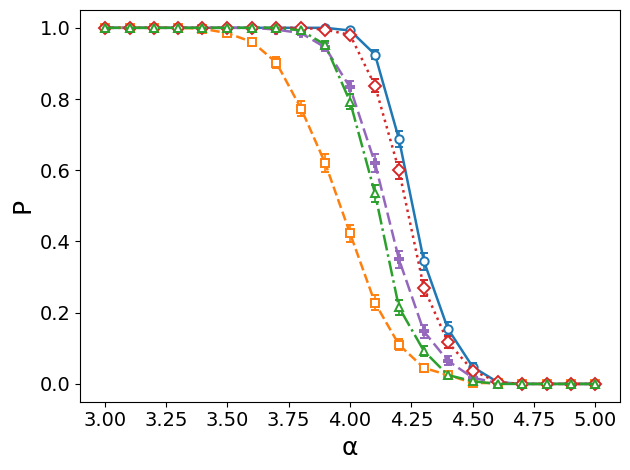

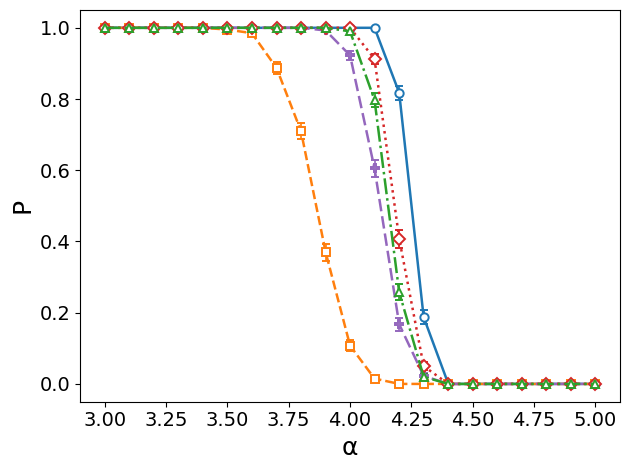

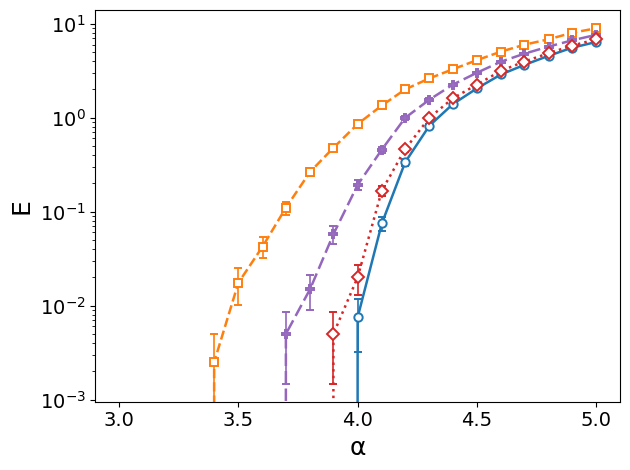

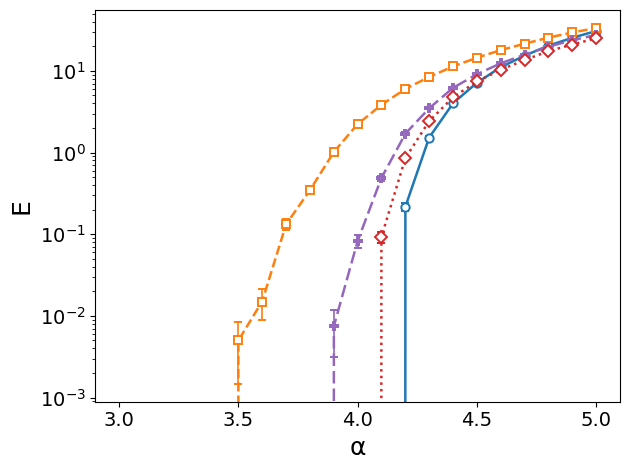

In [12]:
plot_solvability_curve(res_3sat, 256, legend_dict, task='3SAT', savename='fig1_3sat_256.pdf')
plot_solvability_curve(res_3sat, 1024, legend_dict, task='3SAT', savename='fig1_3sat_1024.pdf')
plot_solvability_curve(res_3sat, 256, legend_dict, task='3SAT', value='energy', savename='E_3SAT_256.pdf')
plot_solvability_curve(res_3sat, 1024, legend_dict, task='3SAT', value='energy', savename='E_3SAT_1024.pdf')

In [13]:
res_4sat = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/4SAT-summary.csv'))
res_4sat.algo.value_counts()

algo
SurveyPropagation_frac-decimated=0.00125      231
NeuroSAT_unsupervised_niters=2N_Ntrain=256    168
QuerySAT_niters=2N_Ntrain=256                 168
FMS_nsteps=100N^2                             168
FMS_nsteps=1000N^2                            147
SimulatedAnnealing_nsteps=1000N^2             147
Name: count, dtype: int64

In [14]:
res_4sat = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/4SAT-summary.csv'))
algorithms = sorted(['FMS_nsteps=100N^2', 'NeuroSAT_unsupervised_niters=2N_Ntrain=256', 'SurveyPropagation_frac-decimated=0.00125', 'SimulatedAnnealing_nsteps=1000N^2', 'QuerySAT_niters=2N_Ntrain=256'])
algo_names = sorted(['FMS', 'NeuroSAT', 'SP', 'SA', 'QuerySAT'])
legend_dict = dict(zip(algorithms, algo_names))
res_4sat = res_4sat[res_4sat['algo'] != 'FMS_nsteps=1000N^2']
res_4sat['alpha'] = res_4sat['M'] / res_4sat['N']
res_4sat = res_4sat.drop_duplicates()
res_4sat

,algo,N,M,count,E_mean,E_err,ProbSolv,ProbSolv_err,alpha
147,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,128,200,0.210,0.030564,0.800,0.028355,8.000000
148,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,130,200,0.200,0.028355,0.800,0.028355,8.125000
149,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,131,200,0.215,0.029973,0.790,0.028873,8.187500
150,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,133,200,0.195,0.028086,0.805,0.028086,8.312500
151,NeuroSAT_unsupervised_niters=2N_Ntrain=256,16,134,200,0.225,0.032822,0.790,0.028873,8.375000
...,...,...,...,...,...,...,...,...,...
1024,FMS_nsteps=100N^2,2048,19661,200,0.000,0.000000,1.000,0.000000,9.600098
1025,FMS_nsteps=100N^2,2048,19866,200,0.055,0.017647,0.950,0.015450,9.700195
1026,FMS_nsteps=100N^2,2048,20070,200,0.540,0.051039,0.565,0.035143,9.799805
1027,FMS_nsteps=100N^2,2048,20275,200,2.155,0.089974,0.070,0.018087,9.899902


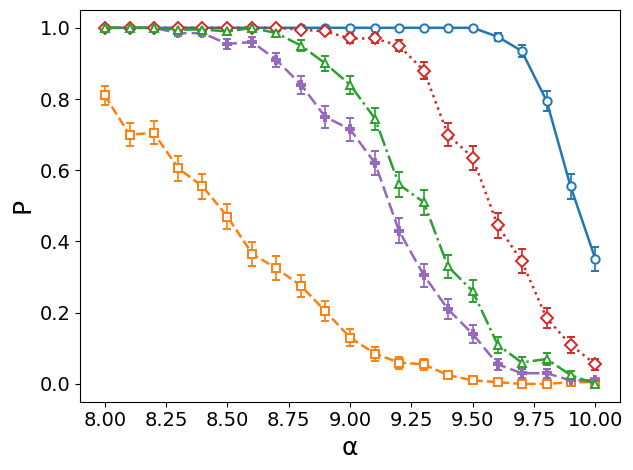

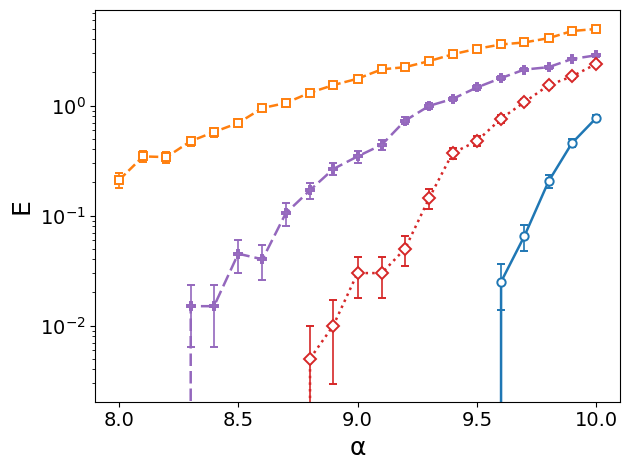

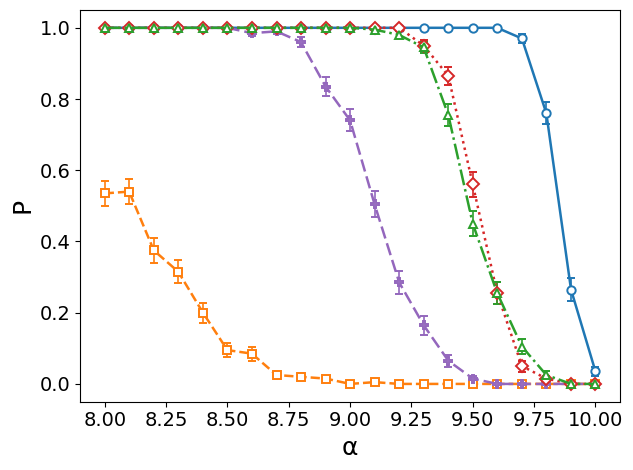

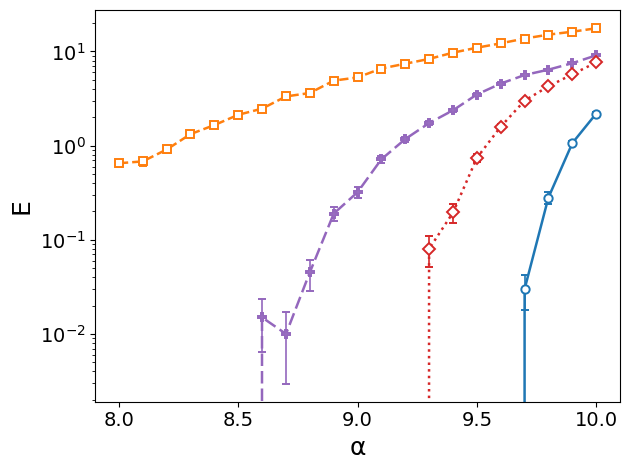

In [15]:
plot_solvability_curve(res_4sat, 256, legend_dict, task='4SAT', savename='fig1_4sat_256.pdf')
plot_solvability_curve(res_4sat, 256, legend_dict, task='4SAT', value='energy', savename='E_4SAT_256.pdf')
plot_solvability_curve(res_4sat, 1024, legend_dict, task='4SAT', savename='fig1_4sat_1024.pdf')
plot_solvability_curve(res_4sat, 1024, legend_dict, task='4SAT', value='energy', savename='E_4SAT_1024.pdf')

In [16]:
save_shared_legend(
    model_order=[
        'FMS',
        'NeuroSAT',
        'QuerySAT',
        'SA',
        'SP',
    ],
    savename='sat_legend.pdf',
    ncol=5,
)

In [17]:
res_3col = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/3COL-summary.csv'))
algorithms = sorted(['BeliefPropagation_frac-decimated=1overN', 'SimulatedAnnealing_nsteps=1000N^2', \
                      'FMScol_eta=0.37_nsteps=625N^2', 'rPI-GNN_ntrials=5', 'QuerySAT_nsteps=2N'])
algo_names = sorted(['BP', 'SA', 'FMS', 'rPI-GNN', 'QuerySAT'])
legend_dict = dict(zip(algorithms, algo_names))
res_3col = res_3col[res_3col['algo'].isin(algorithms)]
res_3col['alpha'] = (res_3col['M'] / res_3col['N']) * 2
res_3col = res_3col[res_3col['alpha'] > 3.25]
res_3col = res_3col.drop_duplicates()

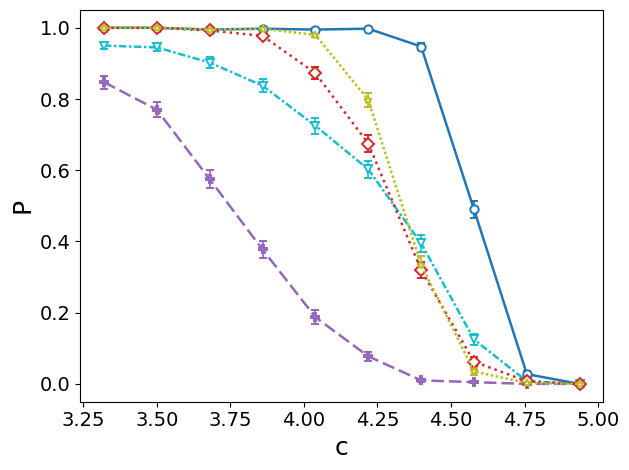

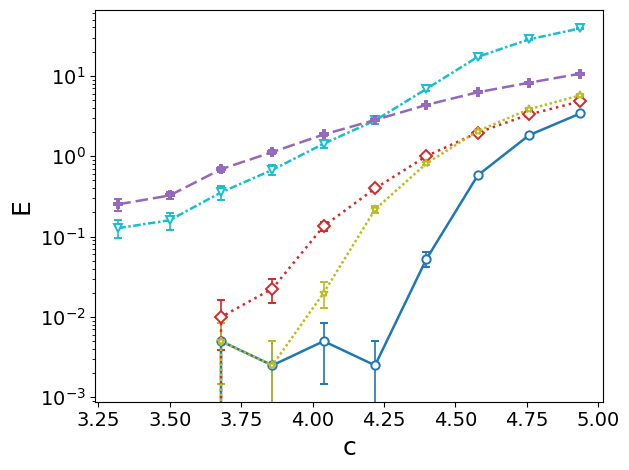

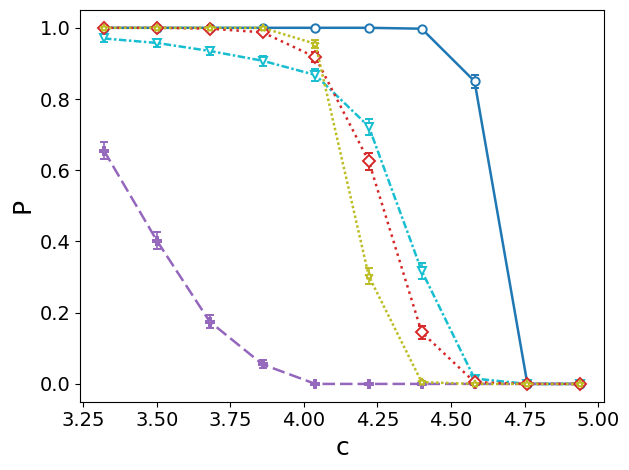

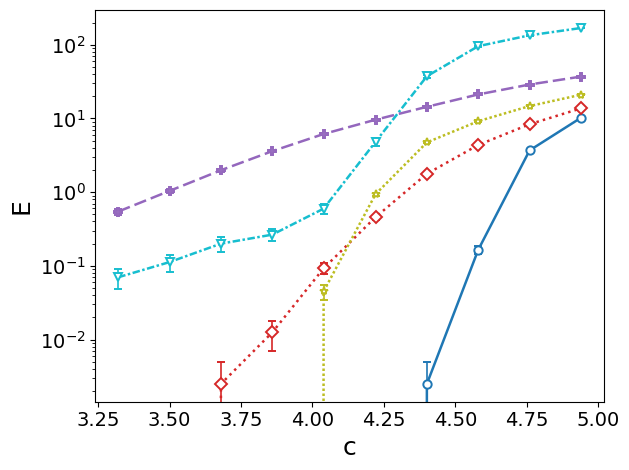

In [18]:
plot_solvability_curve(res_3col, 256, legend_dict, task='3COL', savename='fig1_3col_256.pdf')
plot_solvability_curve(res_3col, 256, legend_dict, task='3COL', value='energy', savename='E_3COL_256.pdf')
plot_solvability_curve(res_3col, 1024, legend_dict, task='3COL', savename='fig1_3col_1024.pdf')
plot_solvability_curve(res_3col, 1024, legend_dict, task='3COL', value='energy', savename='E_3COL_1024.pdf')

In [19]:
res_5col = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/5COL-summary.csv'))
algorithms = sorted(['BeliefPropagation_frac-decimated=1overN', 'SimulatedAnnealing_nsteps=1000N^2', \
                      'FMScol_eta=0.25_nsteps=625N^2', 'rPI-GNN_ntrials=5', 'QuerySAT_nsteps=2N'])
algo_names = sorted(['BP', 'SA', 'FMS', 'rPI-GNN', 'QuerySAT'])
legend_dict = dict(zip(algorithms, algo_names))
res_5col = res_5col[res_5col['algo'].isin(algorithms)]
res_5col['alpha'] = (res_5col['M'] / res_5col['N']) * 2
res_5col = res_5col.drop_duplicates()
res_5col

,algo,N,M,count,E_mean,E_err,ProbSolv,ProbSolv_err,alpha
0,FMScol_eta=0.25_nsteps=625N^2,16,79,400,2.2275,0.034711,0.005,0.003531,9.875000
1,FMScol_eta=0.25_nsteps=625N^2,16,82,400,2.6525,0.036848,0.000,0.000000,10.250000
2,FMScol_eta=0.25_nsteps=625N^2,16,86,400,3.3775,0.037796,0.000,0.000000,10.750000
3,FMScol_eta=0.25_nsteps=625N^2,16,89,400,3.9650,0.036917,0.000,0.000000,11.125000
4,FMScol_eta=0.25_nsteps=625N^2,16,92,400,4.6125,0.036182,0.000,0.000000,11.500000
...,...,...,...,...,...,...,...,...,...
469,rPI-GNN_ntrials=5,4096,21914,400,0.0000,0.000000,1.000,0.000000,10.700195
470,rPI-GNN_ntrials=5,4096,22733,400,0.0000,0.000000,1.000,0.000000,11.100098
471,rPI-GNN_ntrials=5,4096,23552,400,1.5775,0.088485,0.325,0.023448,11.500000
472,rPI-GNN_ntrials=5,4096,24371,400,10.9225,0.175551,0.000,0.000000,11.899902


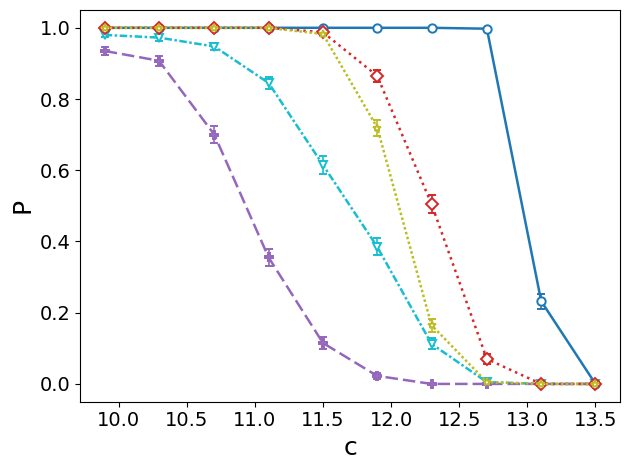

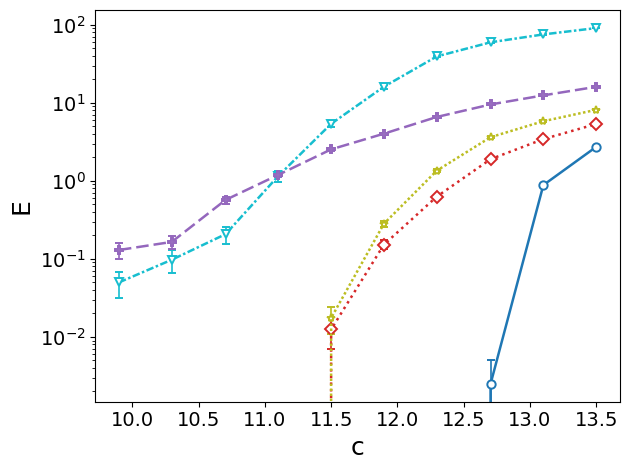

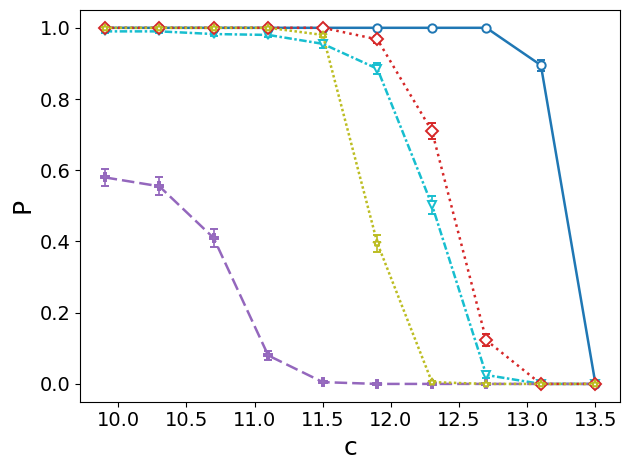

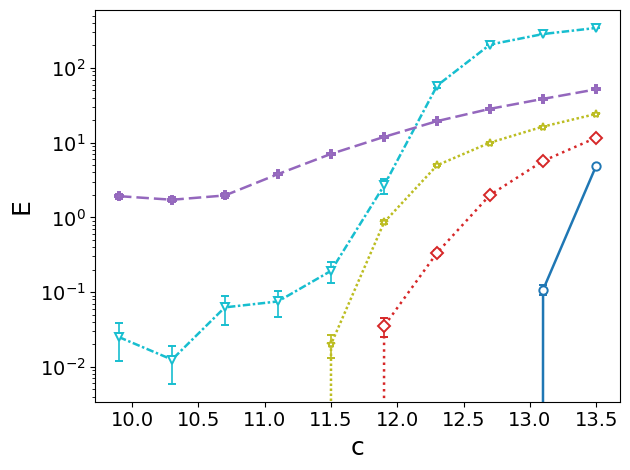

In [20]:
plot_solvability_curve(res_5col, 256, legend_dict, task='5COL', savename='fig1_5col_256.pdf')
plot_solvability_curve(res_5col, 256, legend_dict, task='5COL', value='energy', savename='E_5COL_256.pdf')
plot_solvability_curve(res_5col, 1024, legend_dict, task='5COL', savename='fig1_5col_1024.pdf')
plot_solvability_curve(res_5col, 1024, legend_dict, task='5COL', value='energy', savename='E_5COL_1024.pdf')

In [21]:
save_shared_legend(
    model_order=[
        'BP',
        'FMS',
        'QuerySAT',
        'SA',
        'rPI-GNN',
    ],
    savename='coloring_legend.pdf',
    ncol=5,
)

# Fig 2

In [22]:
N_color_dict = {
    16: 'tab:blue',
    32: 'tab:orange',
    64: 'tab:green',
    128: 'tab:red',
    256: 'tab:purple',
    512: 'tab:brown',
    1024: 'tab:pink',
    2048: 'tab:olive',
    4096: 'tab:cyan',
    8192: 'darkmagenta',
    16384: 'sienna',
}

N_style_dict = {
    16:    {'linestyle': '-',              'marker': 'o'},
    32:    {'linestyle': '--',             'marker': 's'},
    64:    {'linestyle': '-.',             'marker': '^'},
    128:   {'linestyle': ':',              'marker': 'D'},
    256:   {'linestyle': (0, (5, 2)),      'marker': 'v'},
    512:   {'linestyle': (0, (3, 1, 1, 1)), 'marker': 'P'},
    1024:  {'linestyle': (0, (1, 1)),      'marker': 'X'},
    2048:  {'linestyle': (0, (5, 1, 1, 1)), 'marker': '<'},
    4096:  {'linestyle': (0, (3, 2)),      'marker': '>'},
    8192:  {'linestyle': (0, (1, 2)),      'marker': 'h'},
    16384: {'linestyle': (0, (4, 1, 1, 1)), 'marker': '*'},
}

def plot_model_curve(
    results_df,
    curve_type='probability',
    savename=None,
    show_legend=False,
):
    assert curve_type in [
        'probability',
        'ext_energy',
        'int_energy',
    ], 'Invalid curve type'

    fig, ax = plt.subplots()

    for N, group in results_df.groupby('N'):
        alphas = []
        means = []
        sems = []

        for alpha, alpha_data in group.groupby('alpha'):
            if curve_type == 'probability':
                values = alpha_data['Solved']

                mean = values.mean()
                sem = values.std() / np.sqrt(len(values))

            elif curve_type == 'ext_energy':
                values = alpha_data['Efinale']

                mean = values.mean()
                sem = values.std() / np.sqrt(len(values))

            else:
                values = alpha_data['Efinale']
                number_constraints = round(alpha * N)

                mean = values.mean() / number_constraints
                sem = (
                    values.std()
                    / np.sqrt(len(values))
                    / number_constraints
                )

            alphas.append(alpha)
            means.append(mean)
            sems.append(sem)

        # Sort the points by alpha before connecting them.
        order = np.argsort(alphas)

        alphas = np.asarray(alphas)[order]
        means = np.asarray(means)[order]
        sems = np.asarray(sems)[order]

        style = N_style_dict[N]

        ax.errorbar(
            alphas,
            means,
            yerr=sems,
            label=rf'$N={N}$',
            color=N_color_dict[N],
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=1.8,
            markersize=5,
            markerfacecolor='white',
            markeredgecolor=N_color_dict[N],
            markeredgewidth=1.2,
            capsize=2.5,
            elinewidth=1.0,
        )

    ax.set_xlabel(r'$\alpha$', fontsize=18)

    if curve_type == 'probability':
        ax.set_ylabel(r'$P$', fontsize=18)
        ax.set_ylim(0, 1)
    else:
        ax.set_ylabel(r'$E$', fontsize=18)

        # Remove this if your energy is always normalized to [0, 1].
        # ax.set_yscale('log')

    ax.tick_params(axis='both', labelsize=14)

    if show_legend:
        ax.legend(fontsize=12)

    fig.tight_layout()

    if savename:
        os.makedirs('figures', exist_ok=True)

        fig.savefig(
            os.path.join('figures', savename),
            format='pdf',
            bbox_inches='tight',
        )

    plt.show()
    plt.close(fig)

from matplotlib.lines import Line2D


def save_N_legend(
    N_values,
    savename='N_legend.pdf',
    ncol=None,
    fontsize=12,
):
    if ncol is None:
        ncol = len(N_values)

    handles = []

    for N in N_values:
        style = N_style_dict[N]

        handles.append(
            Line2D(
                [0],
                [0],
                label=rf'$N={N}$',
                color=N_color_dict[N],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=1.8,
                markersize=5,
                markerfacecolor='white',
                markeredgecolor=N_color_dict[N],
                markeredgewidth=1.2,
            )
        )

    fig = plt.figure(figsize=(7.0, 0.55))

    fig.legend(
        handles=handles,
        loc='center',
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        handlelength=2.5,
        handletextpad=0.5,
        columnspacing=1.3,
    )

    os.makedirs('figures', exist_ok=True)

    fig.savefig(
        os.path.join('figures', savename),
        format='pdf',
        bbox_inches='tight',
        pad_inches=0.02,
        transparent=True,
    )

    plt.close(fig)

In [23]:
ns_3sat_sup_32 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_supervised_niters=32_Ntrain=256.csv'))
ns_3sat_sup_512 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_supervised_niters=512_Ntrain=256.csv'))
ns_3sat_sup_2n = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_supervised_niters=2N_Ntrain=256.csv'))
ns_3sat_unsup_32 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_unsupervised_niters=32_Ntrain=256.csv'))
ns_3sat_unsup_512 = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_unsupervised_niters=512_Ntrain=256.csv'))
ns_3sat_unsup_2n = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_NeuroSAT_unsupervised_niters=2N_Ntrain=256.csv'))

In [24]:
ns_3sat_sup_32['alpha'] = ns_3sat_sup_32['M'] / ns_3sat_sup_32['N']
ns_3sat_sup_32['Solved'] = ns_3sat_sup_32['E'].values == 0
ns_3sat_sup_32 = ns_3sat_sup_32[ns_3sat_sup_32['N'] <= 256]

ns_3sat_sup_512['alpha'] = ns_3sat_sup_512['M'] / ns_3sat_sup_512['N']
ns_3sat_sup_512['Solved'] = ns_3sat_sup_512['E'].values == 0
ns_3sat_sup_512 = ns_3sat_sup_512[ns_3sat_sup_512['N'] <= 256]

ns_3sat_sup_2n['alpha'] = ns_3sat_sup_2n['M'] / ns_3sat_sup_2n['N']
ns_3sat_sup_2n['Solved'] = ns_3sat_sup_2n['E'].values == 0
ns_3sat_sup_2n = ns_3sat_sup_2n[ns_3sat_sup_2n['N'] <= 256]

ns_3sat_unsup_32['alpha'] = ns_3sat_unsup_32['M'] / ns_3sat_unsup_32['N']
ns_3sat_unsup_32['Solved'] = ns_3sat_unsup_32['E'].values == 0
ns_3sat_unsup_32 = ns_3sat_unsup_32[ns_3sat_unsup_32['N'] <= 256]

ns_3sat_unsup_512['alpha'] = ns_3sat_unsup_512['M'] / ns_3sat_unsup_512['N']
ns_3sat_unsup_512['Solved'] = ns_3sat_unsup_512['E'].values == 0
ns_3sat_unsup_512 = ns_3sat_unsup_512[ns_3sat_unsup_512['N'] <= 256]

ns_3sat_unsup_2n['alpha'] = ns_3sat_unsup_2n['M'] / ns_3sat_unsup_2n['N']
ns_3sat_unsup_2n['Solved'] = ns_3sat_unsup_2n['E'].values == 0
ns_3sat_unsup_2n = ns_3sat_unsup_2n[ns_3sat_unsup_2n['N'] <= 256]

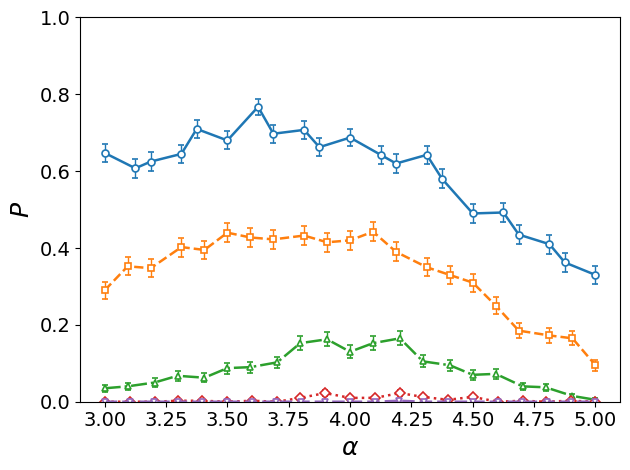

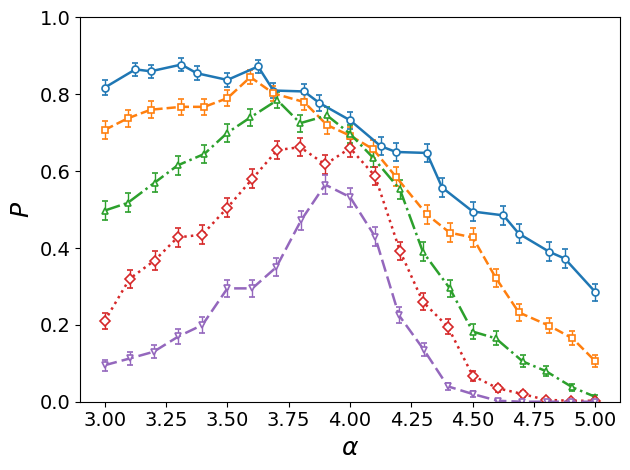

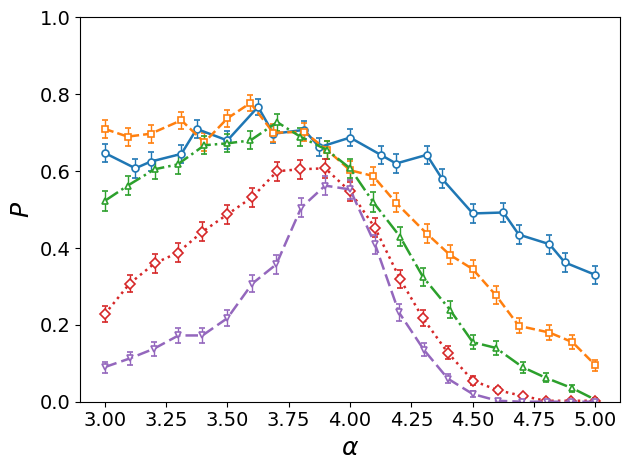

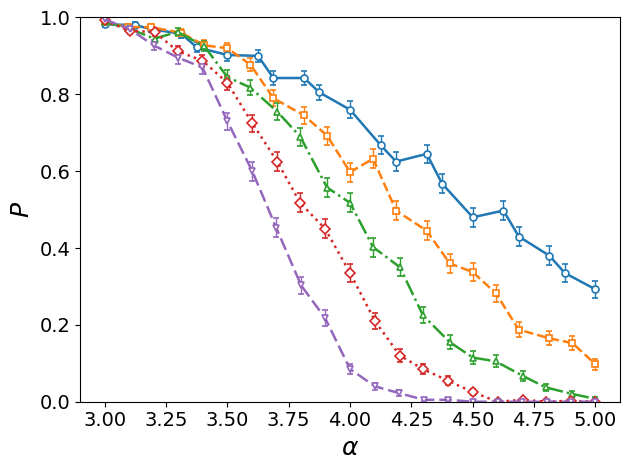

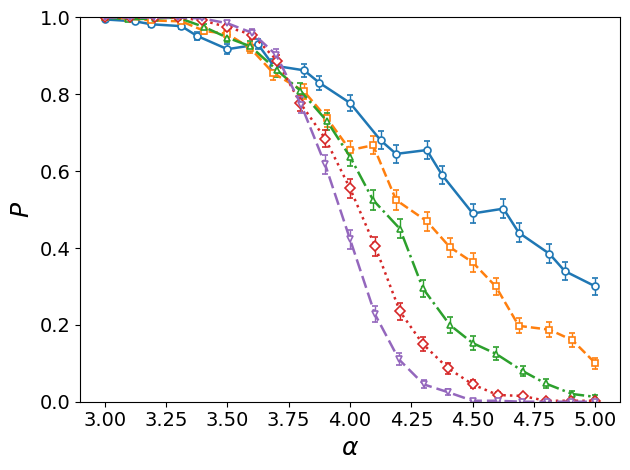

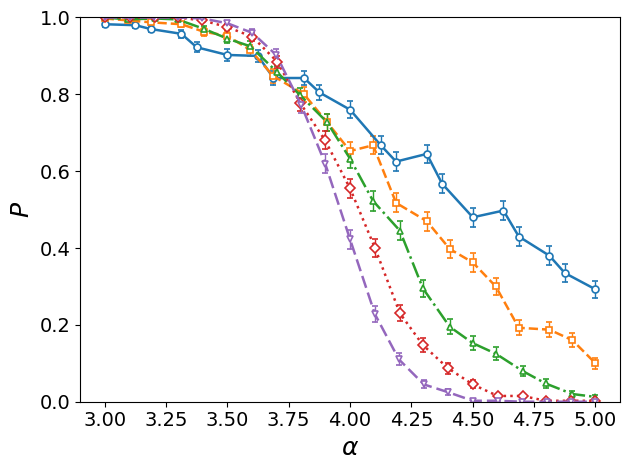

In [25]:
plot_model_curve(ns_3sat_sup_32, curve_type='probability', savename='neurosat_3sat_sup_32.pdf')
plot_model_curve(ns_3sat_sup_512, curve_type='probability', savename='neurosat_3sat_sup_512.pdf')
plot_model_curve(ns_3sat_sup_2n, curve_type='probability', savename='neurosat_3sat_sup_2n.pdf')
plot_model_curve(ns_3sat_unsup_32, curve_type='probability', savename='neurosat_3sat_unsup_32.pdf')
plot_model_curve(ns_3sat_unsup_512, curve_type='probability', savename='neurosat_3sat_unsup_512.pdf')
plot_model_curve(ns_3sat_unsup_2n, curve_type='probability', savename='neurosat_3sat_unsup_2n.pdf')

In [26]:
save_N_legend(
    N_values=[16, 32, 64, 128, 256],
    savename='training_N_legend.pdf',
    ncol=5,
)

# Fig. 3

In [17]:
def logistic_fit(alpha, Q, b, v, alpha_N):
    # Implements a more general logistic function (solution of Richards's DE with K=1)
    return 1 / ((1 + Q * np.exp(-b*v*(alpha - alpha_N))) ** (1/v))

def plot_threshold_curve(results_df, task='3SAT', threshold=0., algorithm=None, savename=None):
    p_curves, err_vals, xs, Ns = [], [], [], []
    grouped_df = results_df.groupby('N')
    for N, group in grouped_df:
        alphas, means, sems = [], [], []
        alpha_group = group.groupby('alpha')
        for a, g in alpha_group:
            p_mean, p_sem = g["Solved"].mean(), g["Solved"].std()/np.sqrt(g["Solved"].shape[0])
            alphas.append(a)
            means.append(p_mean)
            sems.append(p_sem)
        p_curves.append(means)
        err_vals.append(sems)
        Ns.append(N)
        xs.append(alphas)

    popts = []
    for i in range(len(p_curves)):
        x, y = xs[i], p_curves[i]
        if task == '3SAT':
            bounds = ([0., -np.inf, 0., 2.], [np.inf, np.inf, np.inf, 6.])
        elif task == '4SAT':
            bounds = ([0., -np.inf, 0., 7.], [np.inf, np.inf, np.inf, 11.])
        elif task == '3COL':
            bounds = ([0., -np.inf, 0., 2.], [np.inf, np.inf, np.inf, 5.])
        else:
            bounds = ([0., -np.inf, 0., 0.], [np.inf, np.inf, np.inf, np.inf])
        popt, _ = curve_fit(logistic_fit, x, y, bounds=bounds, maxfev=10000)
        popts.append(popt)

    for i in range(len(p_curves)):
        x, y, popt, errors = xs[i], p_curves[i], popts[i], err_vals[i]
        plt.errorbar(x, y, yerr=errors, fmt='o', color=N_color_dict[Ns[i]])

        if task == '3SAT':
            min_x, max_x = 3., 5.
        elif task == '4SAT':
            min_x, max_x = 8., 10.
        elif task == '3COL':
            min_x, max_x = 3.25, 5.
        elif task == '5COL':
            min_x, max_x = 10., 13.5
        else:
            raise ValueError('Task not recognized for threshold plotting')

        f = lambda x: logistic_fit(x, *popt)
        fit_x = np.linspace(min_x, max_x, 10000)

        if algorithm == 'QuerySAT' and Ns[i] > 256:
            plt.plot(fit_x, f(fit_x), linestyle='dashed', label=f'N={Ns[i]}', color=N_color_dict[Ns[i]])
        else:
            plt.plot(fit_x, f(fit_x), label=f'N={Ns[i]}', color=N_color_dict[Ns[i]])

    if threshold > 0:
        plt.axvline(x=threshold, color='black', linestyle='--', label=f'Alg. Threshold')

    # Coordinates for arrow (middle of the plot)
    ymid = 0.5
    if algorithm == 'rPI':
        # Arrow pointing left
        xmid = 4.125
        plt.annotate(
            '', xy=(xmid-0.5, ymid), xytext=(xmid, ymid),
            arrowprops=dict(arrowstyle="->", color='gray', lw=2)
        )
    elif algorithm == 'SP':
        # Arrow pointing right
        xmid = 9.
        plt.annotate(
            '', xy=(xmid+0.5, ymid), xytext=(xmid, ymid),
            arrowprops=dict(arrowstyle="->", color='gray', lw=2)
        )
        
    if 'SAT' in task:
        plt.xlabel('α', fontsize=18)
    else:
        plt.xlabel('c', fontsize=18)

    plt.xticks(fontsize=14)
    plt.ylabel('P', fontsize=18)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14, loc='lower left')
    plt.tight_layout()
    if savename:
        plt.savefig(os.path.join('figures', savename), format="pdf")
    plt.show()

In [18]:
gnn_3col = pd.read_csv(os.path.abspath('../results_evaluation/3COL/3COL_rPI-GNN_ntrials=5.csv'))
querysat_3sat = pd.read_csv(os.path.abspath('../results_evaluation/3SAT/3SAT_QuerySAT_niters=2N_Ntrain=256.csv'))
sp_4sat = pd.read_csv(os.path.abspath('../results_evaluation/4SAT/4SAT_SurveyPropagation_frac-decimated=0.00125.csv'))

In [19]:
gnn_3col['alpha'] = (gnn_3col['M'] / gnn_3col['N'])*2
gnn_3col['Solved'] = gnn_3col['E'].values == 0
gnn_3col = gnn_3col[gnn_3col['N'] >= 128]

querysat_3sat['alpha'] = querysat_3sat['M'] / querysat_3sat['N']
querysat_3sat['Solved'] = querysat_3sat['E'].values == 0

sp_4sat = sp_4sat[sp_4sat['N'] >= 128]
sp_4sat['alpha'] = sp_4sat['M'] / sp_4sat['N']
sp_4sat['Solved'] = sp_4sat['E'].values == 0

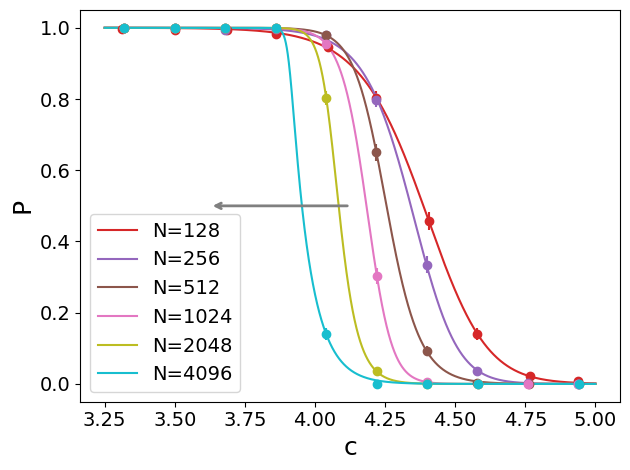

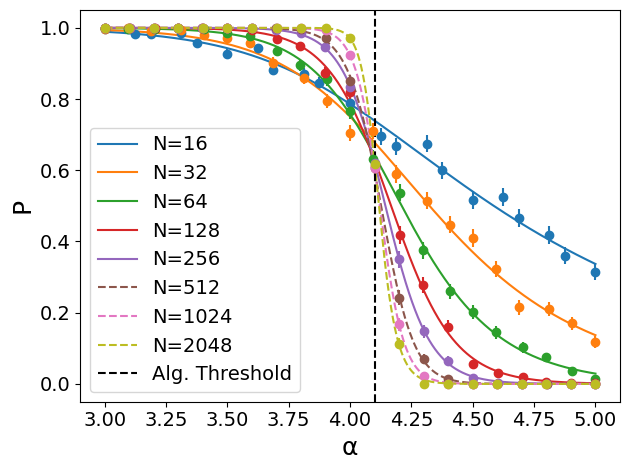

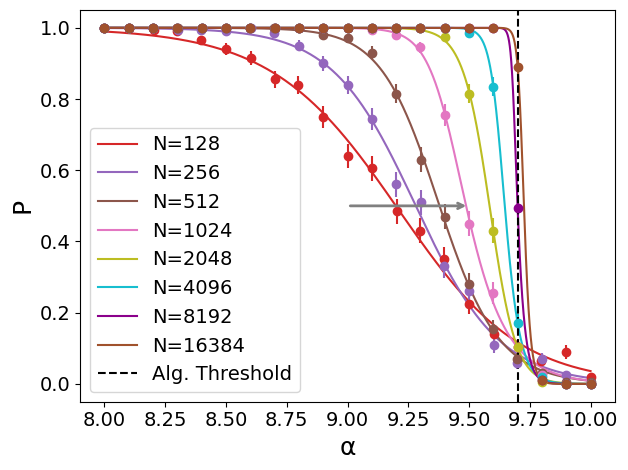

In [20]:
plot_threshold_curve(gnn_3col, task='3COL', algorithm='rPI', savename='rpignn_3col_threshold.pdf')
plot_threshold_curve(querysat_3sat, task='3SAT', algorithm='QuerySAT', threshold=4.1, savename='querysat_3sat_threshold.pdf')
plot_threshold_curve(sp_4sat, task='4SAT', algorithm='SP', threshold=9.7, savename='sp_4sat_threshold.pdf')

# Curves for SP and FMS in large N regimes

In [27]:
def plot_model_curve(
    results_df,
    curve_type='probability',
    task='SAT',
    savename=None,
    show_legend=False,
):
    assert curve_type in [
        'probability',
        'ext_energy',
        'int_energy',
    ], 'Invalid curve type'

    assert task in ['SAT', 'COL'], 'Invalid task type'

    fig, ax = plt.subplots()

    for N, group in results_df.groupby('N'):
        if N not in N_color_dict or N not in N_style_dict:
            continue

        alphas = []
        means = []
        sems = []

        for alpha, alpha_group in group.groupby('alpha'):
            if curve_type == 'probability':
                values = alpha_group['Solved']

                mean = values.mean()
                sem = values.std() / np.sqrt(len(values))

            elif curve_type == 'ext_energy':
                values = alpha_group['E']

                mean = values.mean()
                sem = values.std() / np.sqrt(len(values))

            else:
                values = alpha_group['E']
                number_constraints = round(alpha * N)

                mean = values.mean() / number_constraints
                sem = (
                    values.std()
                    / np.sqrt(len(values))
                    / number_constraints
                )

            alphas.append(alpha)
            means.append(mean)
            sems.append(sem)

        alphas = np.asarray(alphas, dtype=float)
        means = np.asarray(means, dtype=float)
        sems = np.asarray(sems, dtype=float)

        # Ensure that points are connected in increasing alpha/c order.
        order = np.argsort(alphas)
        alphas = alphas[order]
        means = means[order]
        sems = sems[order]

        # Non-positive values cannot be displayed on a logarithmic axis.
        if curve_type == 'ext_energy':
            valid = means > 0
            alphas = alphas[valid]
            means = means[valid]
            sems = sems[valid]

        style = N_style_dict[N]

        ax.errorbar(
            alphas,
            means,
            yerr=sems,
            label=rf'$N={N}$',
            color=N_color_dict[N],
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=1.8,
            markersize=5.5,
            markerfacecolor='white',
            markeredgecolor=N_color_dict[N],
            markeredgewidth=1.3,
            capsize=2.5,
            elinewidth=1.0,
        )

    if curve_type == 'ext_energy':
        ax.set_yscale('log')

    xlabel = r'$\alpha$' if task == 'SAT' else r'$c$'
    ax.set_xlabel(xlabel, fontsize=18)

    if curve_type == 'probability':
        ax.set_ylabel(r'$P$', fontsize=18)
        ax.set_ylim(-0.02, 1.05)
    else:
        ax.set_ylabel(r'$E$', fontsize=18)

    ax.tick_params(axis='both', labelsize=14)

    if show_legend:
        ax.legend(fontsize=12)

    fig.tight_layout()

    if savename:
        os.makedirs('figures', exist_ok=True)

        fig.savefig(
            os.path.join('figures', savename),
            format='pdf',
            bbox_inches='tight',
        )

    plt.show()
    plt.close(fig)

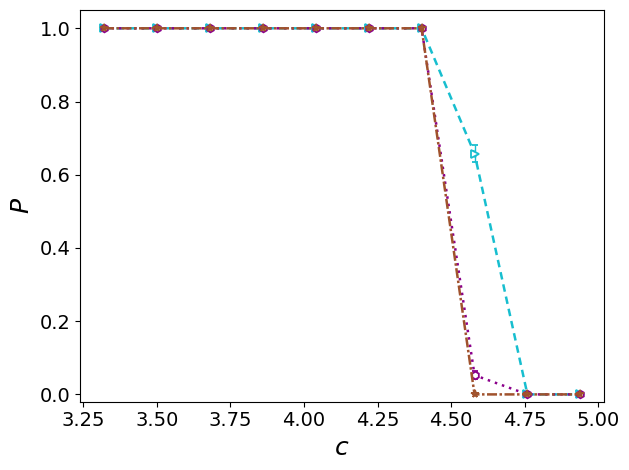

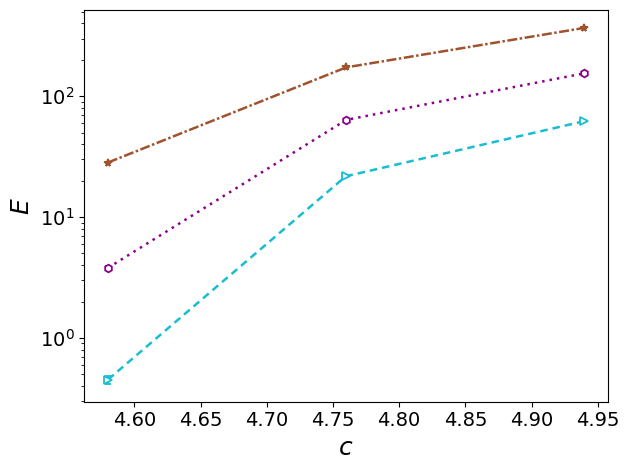

In [28]:
fms_3col = pd.read_csv('../results_evaluation/3COL/3COL_FMScol_eta=0.37_nsteps=625N^2.csv')
fms_3col['alpha'] = fms_3col['M'] / fms_3col['N']*2
fms_3col['Solved'] = fms_3col['E'].values == 0
fms_3col = fms_3col[fms_3col['N'] >= 4096]
plot_model_curve(fms_3col, task='COL', savename='FMS_largeN_3COL_P.pdf')
plot_model_curve(fms_3col, curve_type='ext_energy', task='COL', savename='FMS_largeN_3COL_E.pdf')

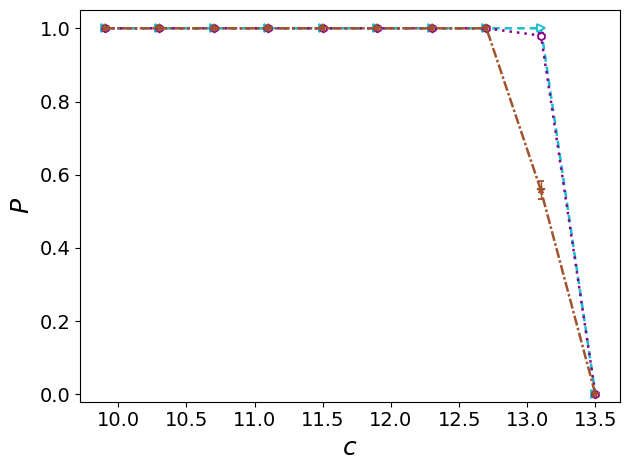

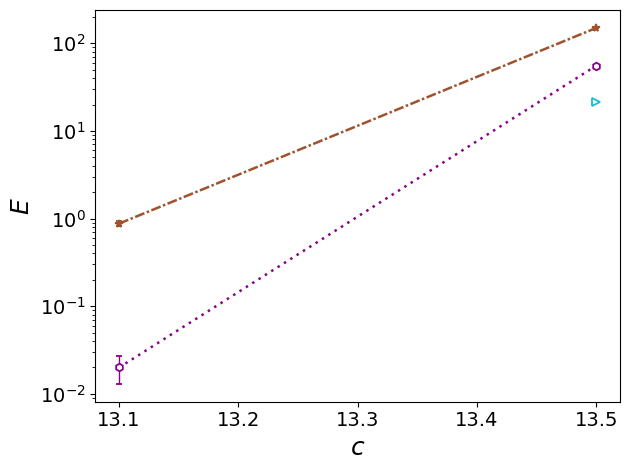

In [29]:
fms_5col = pd.read_csv('../results_evaluation/5COL/5COL_FMScol_eta=0.25_nsteps=625N^2.csv')
fms_5col['alpha'] = fms_5col['M'] / fms_5col['N']*2
fms_5col['Solved'] = fms_5col['E'].values == 0
fms_5col = fms_5col[fms_5col['N'] >= 4096]
plot_model_curve(fms_5col, task='COL', savename='FMS_largeN_5COL_P.pdf')
plot_model_curve(fms_5col, curve_type='ext_energy', task='COL', savename='FMS_largeN_5COL_E.pdf')

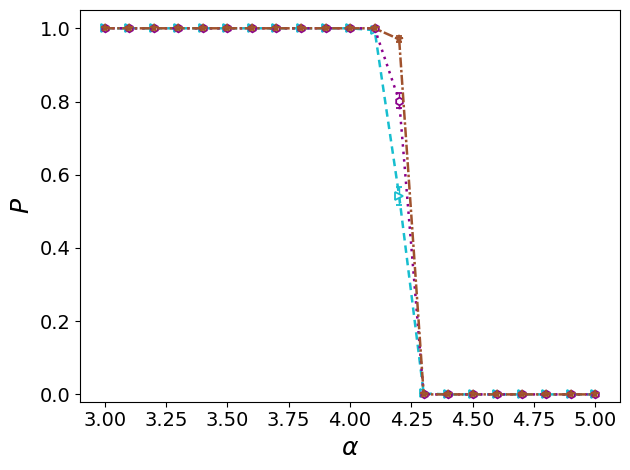

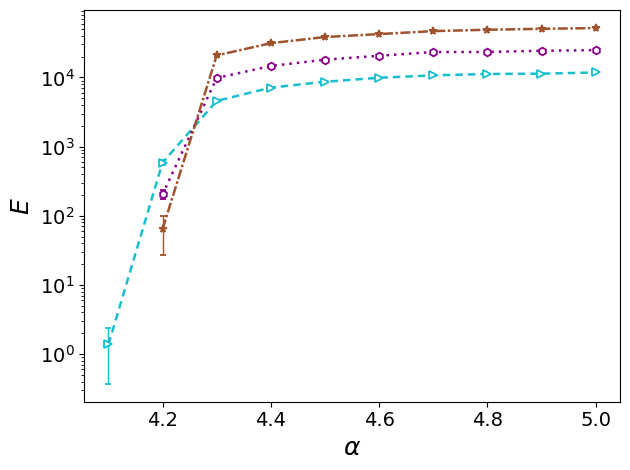

In [30]:
sp_3sat = pd.read_csv('../results_evaluation/3SAT/3SAT_SurveyPropagation_frac-decimated=0.00125.csv')
sp_3sat['alpha'] = sp_3sat['M'] / sp_3sat['N']
sp_3sat['Solved'] = sp_3sat['E'].values == 0
sp_3sat = sp_3sat[sp_3sat['N'] >= 4096]
plot_model_curve(sp_3sat, task='SAT', savename='SP_largeN_3SAT_P.pdf')
plot_model_curve(sp_3sat, curve_type='ext_energy', task='SAT', savename='SP_largeN_3SAT_E.pdf')

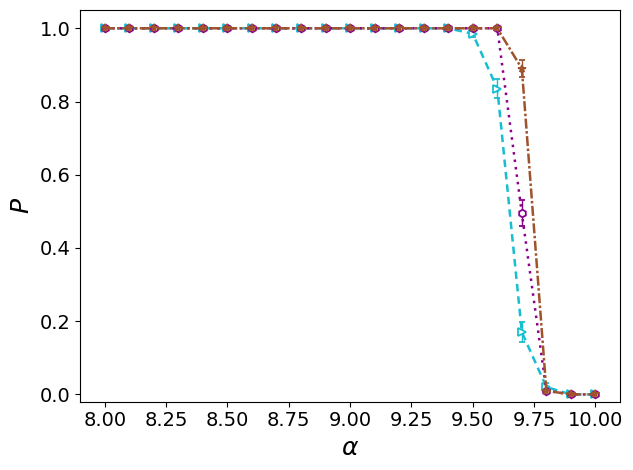

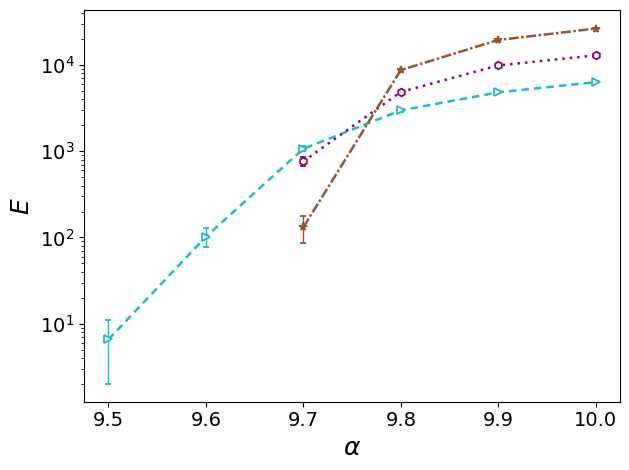

In [31]:
sp_4sat = pd.read_csv('../results_evaluation/4SAT/4SAT_SurveyPropagation_frac-decimated=0.00125.csv')
sp_4sat['alpha'] = sp_4sat['M'] / sp_4sat['N']
sp_4sat['Solved'] = sp_4sat['E'].values == 0
sp_4sat = sp_4sat[sp_4sat['N'] >= 4096]
plot_model_curve(sp_4sat, task='SAT', savename='SP_largeN_4SAT_P.pdf')
plot_model_curve(sp_4sat, curve_type='ext_energy', task='SAT', savename='SP_largeN_4SAT_E.pdf')

In [32]:
save_N_legend(
    N_values=[4096, 8192, 16384],
    savename='supp_large_N_legend.pdf',
    ncol=5,
)

# Cadical vs FMS

In [131]:
# 3SAT
res_3sat = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/3SAT-summary.csv'))
fms_3sat = res_3sat[res_3sat['algo'] == 'FMS_nsteps=100N^2']
fms_3sat['alpha'] = res_3sat['M'] / res_3sat['N']
print(fms_3sat.head())

cadical_3sat = pd.read_csv(os.path.abspath('/home/geri/workspace/Benchmarks_SAT/datasets/3SAT/sc/test_labels-final.csv'))
cadical_3sat = cadical_3sat.copy()
cadical_3sat['sat'] = cadical_3sat['sat'].clip(lower=0)
cadical_3sat['N'] = cadical_3sat['cnf_file'].str.extract(r'N(\d+)_M(\d+)_id\d+\.cnf')[0].astype(int)
cadical_3sat['M'] = cadical_3sat['cnf_file'].str.extract(r'N(\d+)_M(\d+)_id\d+\.cnf')[1].astype(int)
cadical_3sat['alpha'] = cadical_3sat['M'] / cadical_3sat['N']
max_N = cadical_3sat['N'].max()
cadical_3sat = cadical_3sat.groupby(['N', 'M', 'alpha']).agg({'sat': ['mean', 'std', 'count']}).reset_index()
cadical_3sat
print(cadical_3sat.head())

fms_3sat = fms_3sat[fms_3sat['N'] <= max_N]
assert fms_3sat.shape[0] == cadical_3sat.shape[0], "Mismatch in number of instances between FMS results and CaDiCaL test set"

/tmp/ipykernel_102097/2665367234.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fms_3sat['alpha'] = res_3sat['M'] / res_3sat['N']


                  algo   N   M  count  E_mean     E_err  ProbSolv  \
483  FMS_nsteps=100N^2  16  48    400  0.0000  0.000000    1.0000   
484  FMS_nsteps=100N^2  16  50    400  0.0050  0.003531    0.9950   
485  FMS_nsteps=100N^2  16  51    400  0.0100  0.004981    0.9900   
486  FMS_nsteps=100N^2  16  53    400  0.0025  0.002500    0.9975   
487  FMS_nsteps=100N^2  16  54    400  0.0125  0.005562    0.9875   

     ProbSolv_err   alpha  
483      0.000000  3.0000  
484      0.003531  3.1250  
485      0.004981  3.1875  
486      0.002500  3.3125  
487      0.005562  3.3750  
    N   M   alpha     sat                
                     mean       std count
0  16  48  3.0000  1.0000  0.000000   400
1  16  50  3.1250  0.9950  0.070622   400
2  16  51  3.1875  0.9900  0.099623   400
3  16  53  3.3125  0.9975  0.050000   400
4  16  54  3.3750  0.9875  0.111242   400


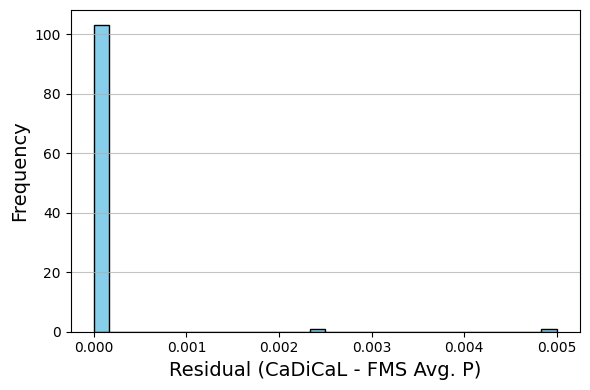

In [132]:
# plot residual distribution
res = cadical_3sat['sat']['mean'].values - fms_3sat['ProbSolv'].values
plt.figure(figsize=(6, 4))
plt.hist(res, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Residual (CaDiCaL - FMS Avg. P)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'residual_distribution.pdf'), format='pdf', bbox_inches='tight')
plt.show()

In [133]:
comparison_style_dict = {
    'FMS': {
        'color': 'tab:blue',
        'linestyle': '-',
        'marker': 'o',
    },
    'CaDiCaL': {
        'color': 'tab:orange',
        'linestyle': '--',
        'marker': 's',
    },
}


def _prepare_cadical_dataframe(cadical_df):
    """
    Convert the grouped CaDiCaL dataframe into the same probability/error
    format used by the FMS dataframe.
    """
    df = cadical_df.copy()

    # Flatten columns such as:
    # ('N', ''), ('sat', 'mean'), ('sat', 'std'), ('sat', 'count')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            '_'.join(
                str(level) for level in column if str(level) != ''
            )
            for column in df.columns.to_flat_index()
        ]

    required_columns = {
        'N',
        'alpha',
        'sat_mean',
        'sat_std',
        'sat_count',
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            'The CaDiCaL dataframe is missing the following columns: '
            f'{sorted(missing_columns)}'
        )

    df['ProbSolv'] = df['sat_mean']

    # The grouped dataframe contains the sample standard deviation.
    # Convert it into the standard error of the mean.
    df['ProbSolv_err'] = (
        df['sat_std'] / np.sqrt(df['sat_count'])
    ).fillna(0.0)

    return df[
        [
            'N',
            'alpha',
            'ProbSolv',
            'ProbSolv_err',
        ]
    ]


def _prepare_fms_dataframe(fms_df, fms_algo=None):
    """
    Select the requested FMS algorithm and retain the columns needed
    for plotting.
    """
    df = fms_df.copy()

    required_columns = {
        'N',
        'alpha',
        'ProbSolv',
        'ProbSolv_err',
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            'The FMS dataframe is missing the following columns: '
            f'{sorted(missing_columns)}'
        )

    if 'algo' in df.columns:
        available_algorithms = df['algo'].dropna().unique()

        if fms_algo is not None:
            if fms_algo not in available_algorithms:
                raise ValueError(
                    f'Algorithm {fms_algo!r} was not found. '
                    f'Available algorithms: {list(available_algorithms)}'
                )

            df = df[df['algo'] == fms_algo]

        elif len(available_algorithms) > 1:
            raise ValueError(
                'The FMS dataframe contains multiple algorithms. '
                'Specify the desired one using fms_algo. '
                f'Available algorithms: {list(available_algorithms)}'
            )

    return df[
        [
            'N',
            'alpha',
            'ProbSolv',
            'ProbSolv_err',
        ]
    ]


def plot_fms_cadical_solvability(
    fms_df,
    cadical_df,
    task,
    N,
    fms_algo=None,
    savename=None,
    show_legend=False,
    show=True,
):
    """
    Plot FMS and CaDiCaL solving probabilities for one system size.

    Parameters
    ----------
    fms_df : pandas.DataFrame
        FMS dataframe containing N, alpha, ProbSolv and ProbSolv_err.

    cadical_df : pandas.DataFrame
        Grouped CaDiCaL dataframe with multi-level sat columns.

    N : int
        System size to plot.

    fms_algo : str or None
        Algorithm to select when fms_df contains more than one value
        in its 'algo' column.

    savename : str or None
        PDF filename saved inside the figures directory.

    show_legend : bool
        Whether to include a legend in this individual plot.

    show : bool
        Whether to display the figure interactively.
    """
    fms_plot_df = _prepare_fms_dataframe(
        fms_df,
        fms_algo=fms_algo,
    )

    cadical_plot_df = _prepare_cadical_dataframe(cadical_df)

    fms_plot_df = (
        fms_plot_df[fms_plot_df['N'] == N]
        .sort_values('alpha')
    )

    cadical_plot_df = (
        cadical_plot_df[cadical_plot_df['N'] == N]
        .sort_values('alpha')
    )

    if fms_plot_df.empty:
        raise ValueError(f'No FMS data were found for N={N}.')

    if cadical_plot_df.empty:
        raise ValueError(f'No CaDiCaL data were found for N={N}.')

    fig, ax = plt.subplots(figsize=(6, 4))

    datasets = {
        'FMS': fms_plot_df,
        'CaDiCaL': cadical_plot_df,
    }

    for method, method_df in datasets.items():
        style = comparison_style_dict[method]

        alphas = method_df['alpha'].to_numpy() if task == 'SAT' else method_df['alpha'].to_numpy() * 2

        ax.errorbar(
            alphas,
            method_df['ProbSolv'].to_numpy(),
            yerr=method_df['ProbSolv_err'].to_numpy(),
            label=method,
            color=style['color'],
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=1.8,
            markersize=6,
            markerfacecolor='white',
            markeredgecolor=style['color'],
            markeredgewidth=1.4,
            capsize=3,
            elinewidth=1.2,
        )

    ax.set_xlabel(r'$\alpha$', fontsize=18)
    ax.set_ylabel(r'$P$', fontsize=18)

    ax.set_ylim(-0.02, 1.02)
    ax.tick_params(axis='both', labelsize=14)

    if show_legend:
        ax.legend(fontsize=14)

    fig.tight_layout()

    if savename:
        os.makedirs('figures', exist_ok=True)

        fig.savefig(
            os.path.join('figures', savename),
            format='pdf',
            bbox_inches='tight',
        )

    if show:
        plt.show()

    plt.close(fig)

    return fig, ax

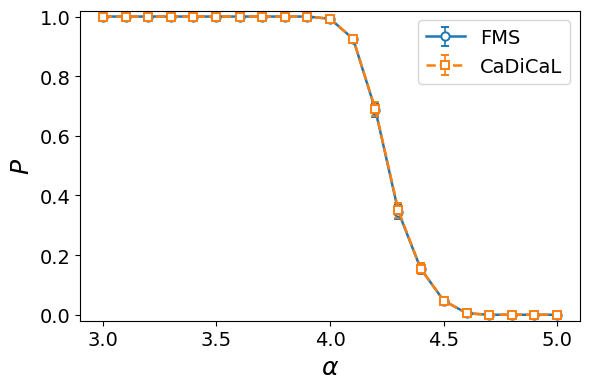

(<Figure size 600x400 with 1 Axes>, <Axes: xlabel='$\\alpha$', ylabel='$P$'>)

In [134]:
plot_fms_cadical_solvability(
    fms_df=fms_3sat,
    cadical_df=cadical_3sat,
    task='SAT',
    N=256,
    fms_algo='FMS_nsteps=100N^2',
    savename='fms_vs_cadical_3sat_N256.pdf',
    show_legend=True,
    show=True
)

In [135]:
# 3COL
res_3col = pd.read_csv(os.path.abspath('../results_evaluation/analysis-results/3COL-summary.csv'))
fms_3col = res_3col[res_3col['algo'] == 'FMScol_eta=0.37_nsteps=625N^2']
fms_3col['alpha'] = res_3col['M'] / res_3col['N']
print(fms_3col.head())

cadical_3col = pd.read_csv(os.path.abspath('/home/geri/workspace/Benchmarks_SAT/datasets/3COL/3COL-test-labels.csv'))
cadical_3col = cadical_3col.copy()
cadical_3col['sat'] = cadical_3col['sat'].clip(lower=0)
cadical_3col['N'] = cadical_3col['cnf_file'].str.extract(r'N(\d+)_M(\d+)_id\d+\.cnf')[0].astype(int)
cadical_3col['M'] = cadical_3col['cnf_file'].str.extract(r'N(\d+)_M(\d+)_id\d+\.cnf')[1].astype(int)
cadical_3col['alpha'] = cadical_3col['M'] / cadical_3col['N']
max_N = cadical_3col['N'].max()
cadical_3col = cadical_3col.groupby(['N', 'M', 'alpha']).agg({'sat': ['mean', 'std', 'count']}).reset_index()
cadical_3col
print(cadical_3col.head())

fms_3col = fms_3col[fms_3col['N'] <= max_N]
assert fms_3col.shape[0] == cadical_3col.shape[0], "Mismatch in number of instances between FMS results and CaDiCaL test set"

/tmp/ipykernel_102097/622304467.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fms_3col['alpha'] = res_3col['M'] / res_3col['N']


                              algo   N   M  count  E_mean     E_err  ProbSolv  \
367  FMScol_eta=0.37_nsteps=625N^2  16  27    400  0.2000  0.020025    0.8000   
368  FMScol_eta=0.37_nsteps=625N^2  16  28    400  0.2050  0.020518    0.7975   
369  FMScol_eta=0.37_nsteps=625N^2  16  29    400  0.3200  0.023884    0.6850   
370  FMScol_eta=0.37_nsteps=625N^2  16  31    400  0.5125  0.027641    0.5150   
371  FMScol_eta=0.37_nsteps=625N^2  16  32    400  0.6350  0.030319    0.4325   

     ProbSolv_err   alpha  
367      0.020025  1.6875  
368      0.020118  1.7500  
369      0.023255  1.8125  
370      0.025020  1.9375  
371      0.024802  2.0000  
    N   M   alpha     sat                
                     mean       std count
0  16  27  1.6875  0.8000  0.400501   400
1  16  28  1.7500  0.7975  0.402366   400
2  16  29  1.8125  0.6850  0.465098   400
3  16  31  1.9375  0.5150  0.500401   400
4  16  32  2.0000  0.4325  0.496043   400


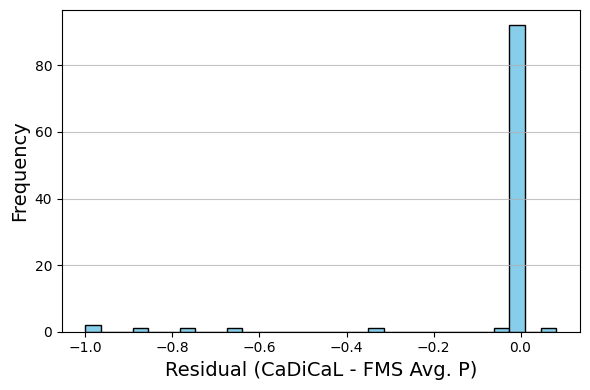

In [136]:
# plot residual distribution
res = cadical_3col['sat']['mean'].values - fms_3col['ProbSolv'].values
plt.figure(figsize=(6, 4))
plt.hist(res, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Residual (CaDiCaL - FMS Avg. P)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig(os.path.join('figures', 'col_residual_distribution.pdf'), format='pdf', bbox_inches='tight')
plt.show()

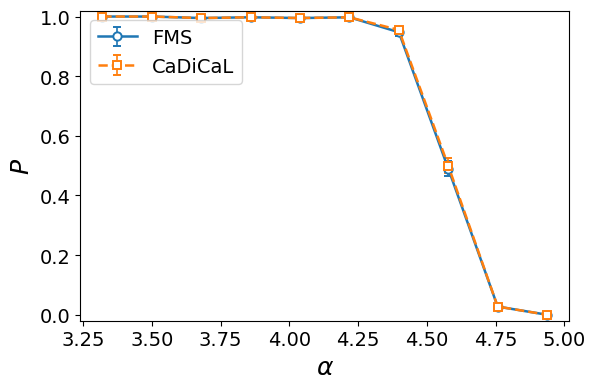

(<Figure size 600x400 with 1 Axes>, <Axes: xlabel='$\\alpha$', ylabel='$P$'>)

In [137]:
plot_fms_cadical_solvability(
    fms_df=fms_3col,
    cadical_df=cadical_3col,
    task='COL',
    N=256,
    fms_algo='FMScol_eta=0.37_nsteps=625N^2',
    savename='fms_vs_cadical_3col_N256.pdf',
    show_legend=True,
    show=True
)